In [27]:
import psychometric_fxns as pf
import psignifit as ps
import psignifit.psigniplot as psp
import matplotlib.pyplot as plt

In [32]:
import os

repo_dir = os.getcwd()
data_dir = os.path.join(repo_dir, 'tilt_mocs','data')
#loop thru subjects (only the directories that start with sub there are no letters after sub just numbers, so not sub-eliza but yes sub-21040096)
all_subs = [d for d in os.listdir(data_dir) if d.startswith('sub-') and d[4:].isdigit()]
#get the subs whose IDs are greater than or equal to 21049995
stair_subs = [d for d in all_subs if int(d[4:]) >= 21049995]
#get the subs whose IDs are less than 21049995
fixed_subs = [d for d in all_subs if int(d[4:]) < 21049995]
#get the subs whose IDs are less than 21040200 but greater than 21040098
real_subs = [d for d in all_subs if int(d[4:]) < 21040200 and int(d[4:]) > 21040098]

# Collect all subject data
data_files = {}
for sub in real_subs:
    data_files[sub] = {}
    sub_path = os.path.join(data_dir, sub)
    if os.path.exists(sub_path):
        # Look for ses- folders
        sessions = sorted([s for s in os.listdir(sub_path) if s.startswith('ses-')])
        for ses in sessions:
            sub_data_dir = os.path.join(sub_path, ses)
            if os.path.isdir(sub_data_dir):
                csv_files = [f for f in os.listdir(sub_data_dir) if f.endswith('.csv')]
                if csv_files:
                    data_files[sub][ses] = os.path.join(sub_data_dir, csv_files[0])

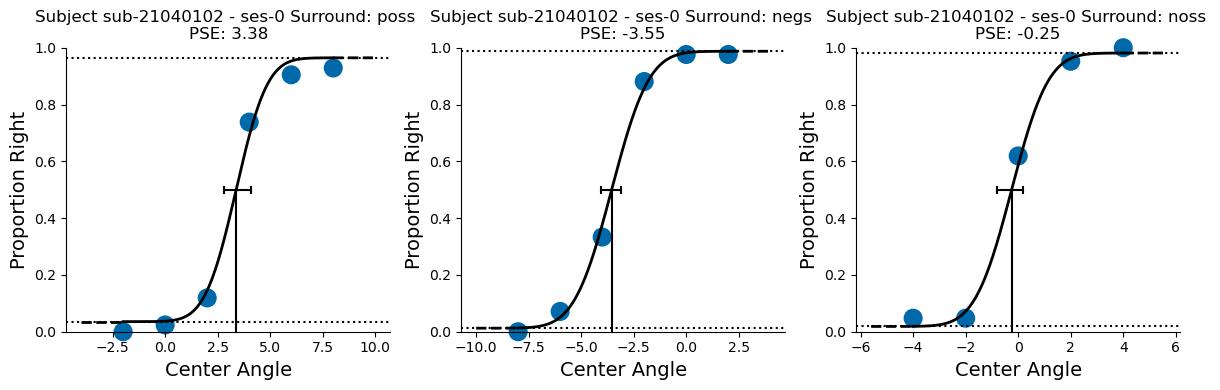

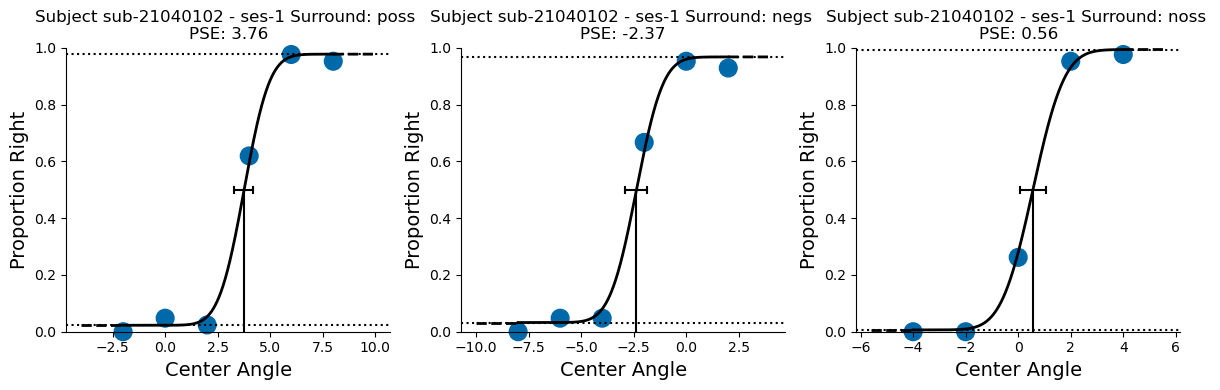

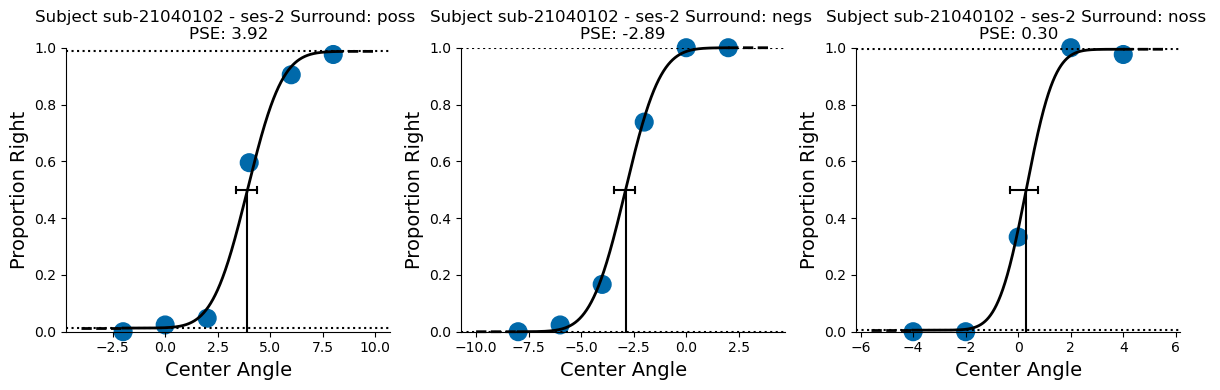

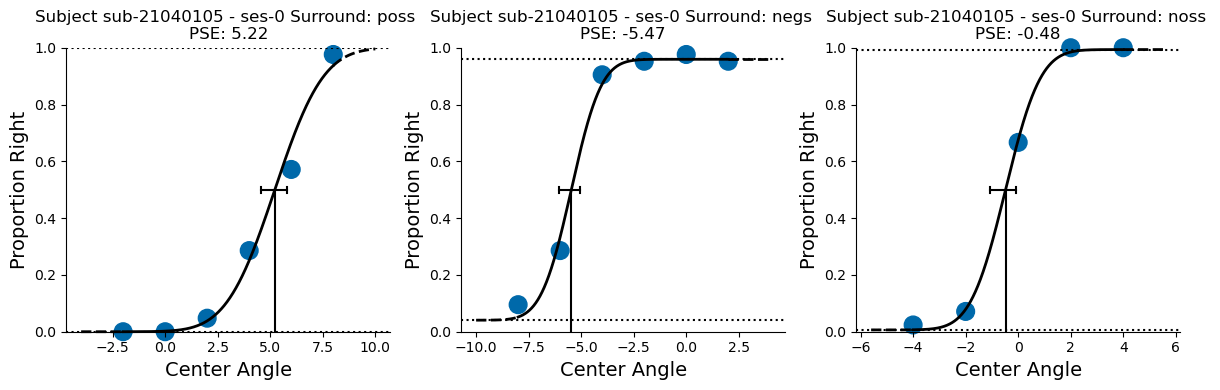

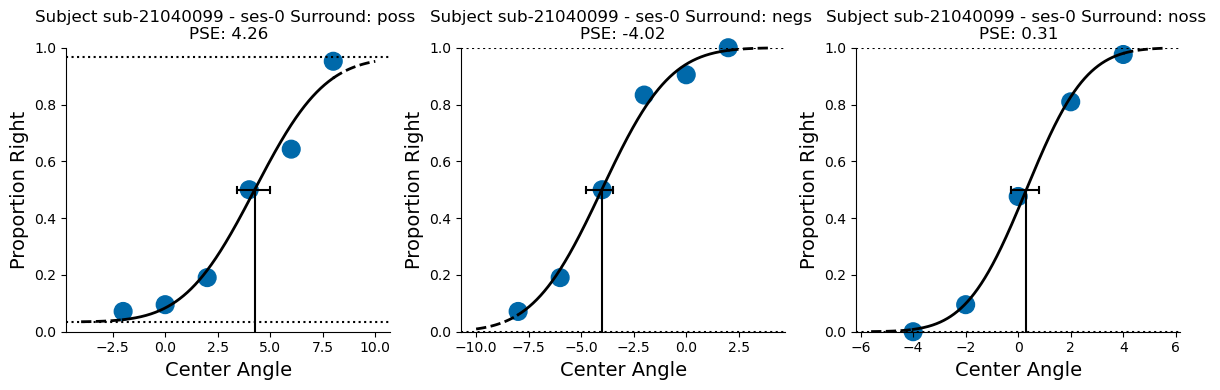

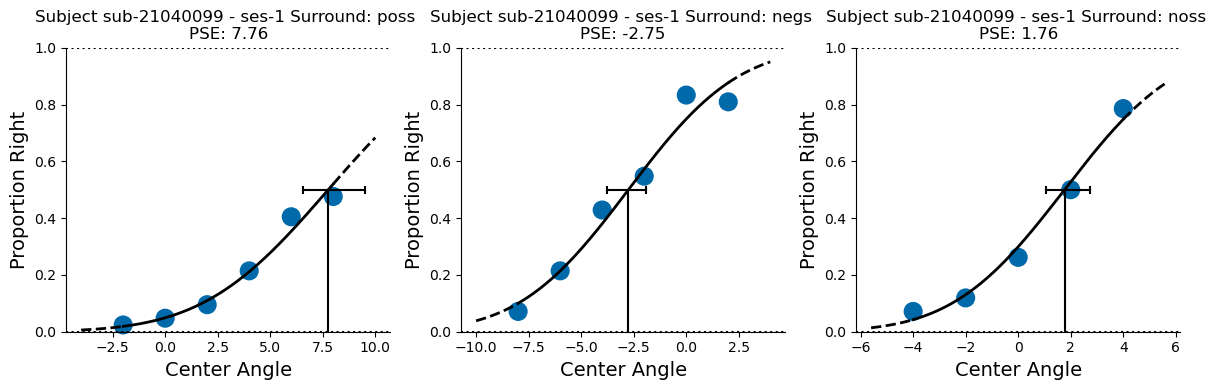

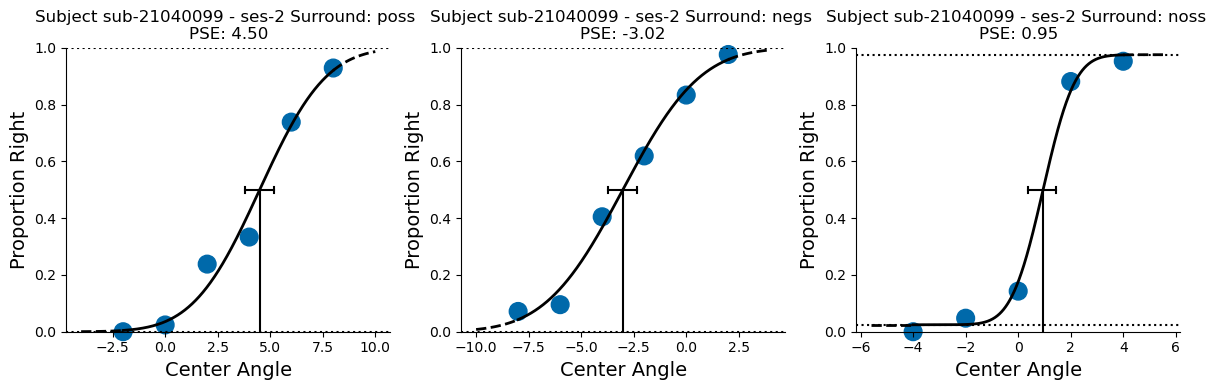

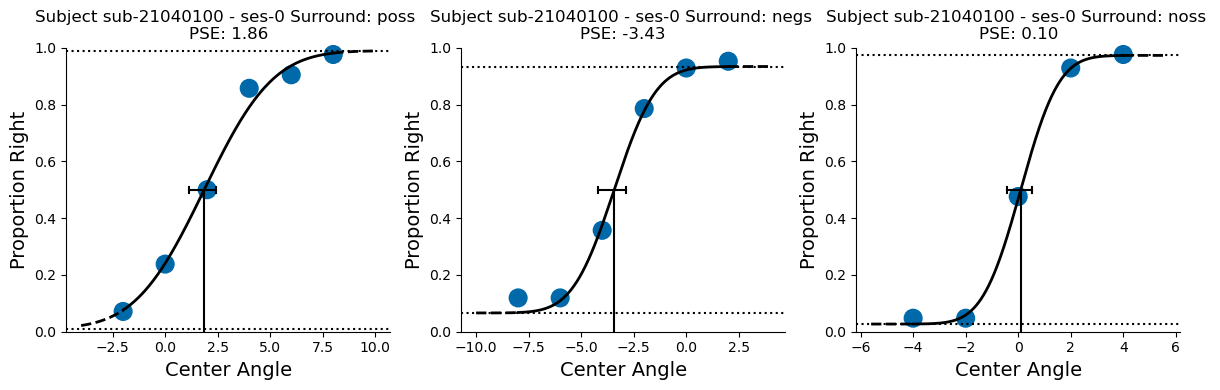

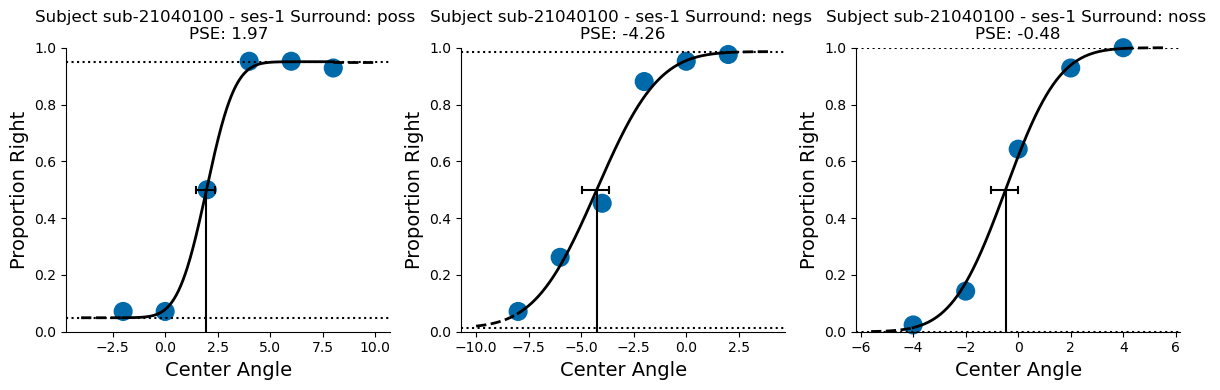

In [33]:
# plot each subject's psychometric function individually (already there)
# also create a mega plot with all of the individual plots on one figure
for sub, sessions in data_files.items():
    for ses, file_path in sessions.items():
        test = pf.get_psignifit_data_from_mocs_csv(file_path)
        fit_results = pf.fit_psychometric_fxn(test)
        pf.plot_psychometric_fxns(fit_results, f'{sub} - {ses}')
        plt.show()

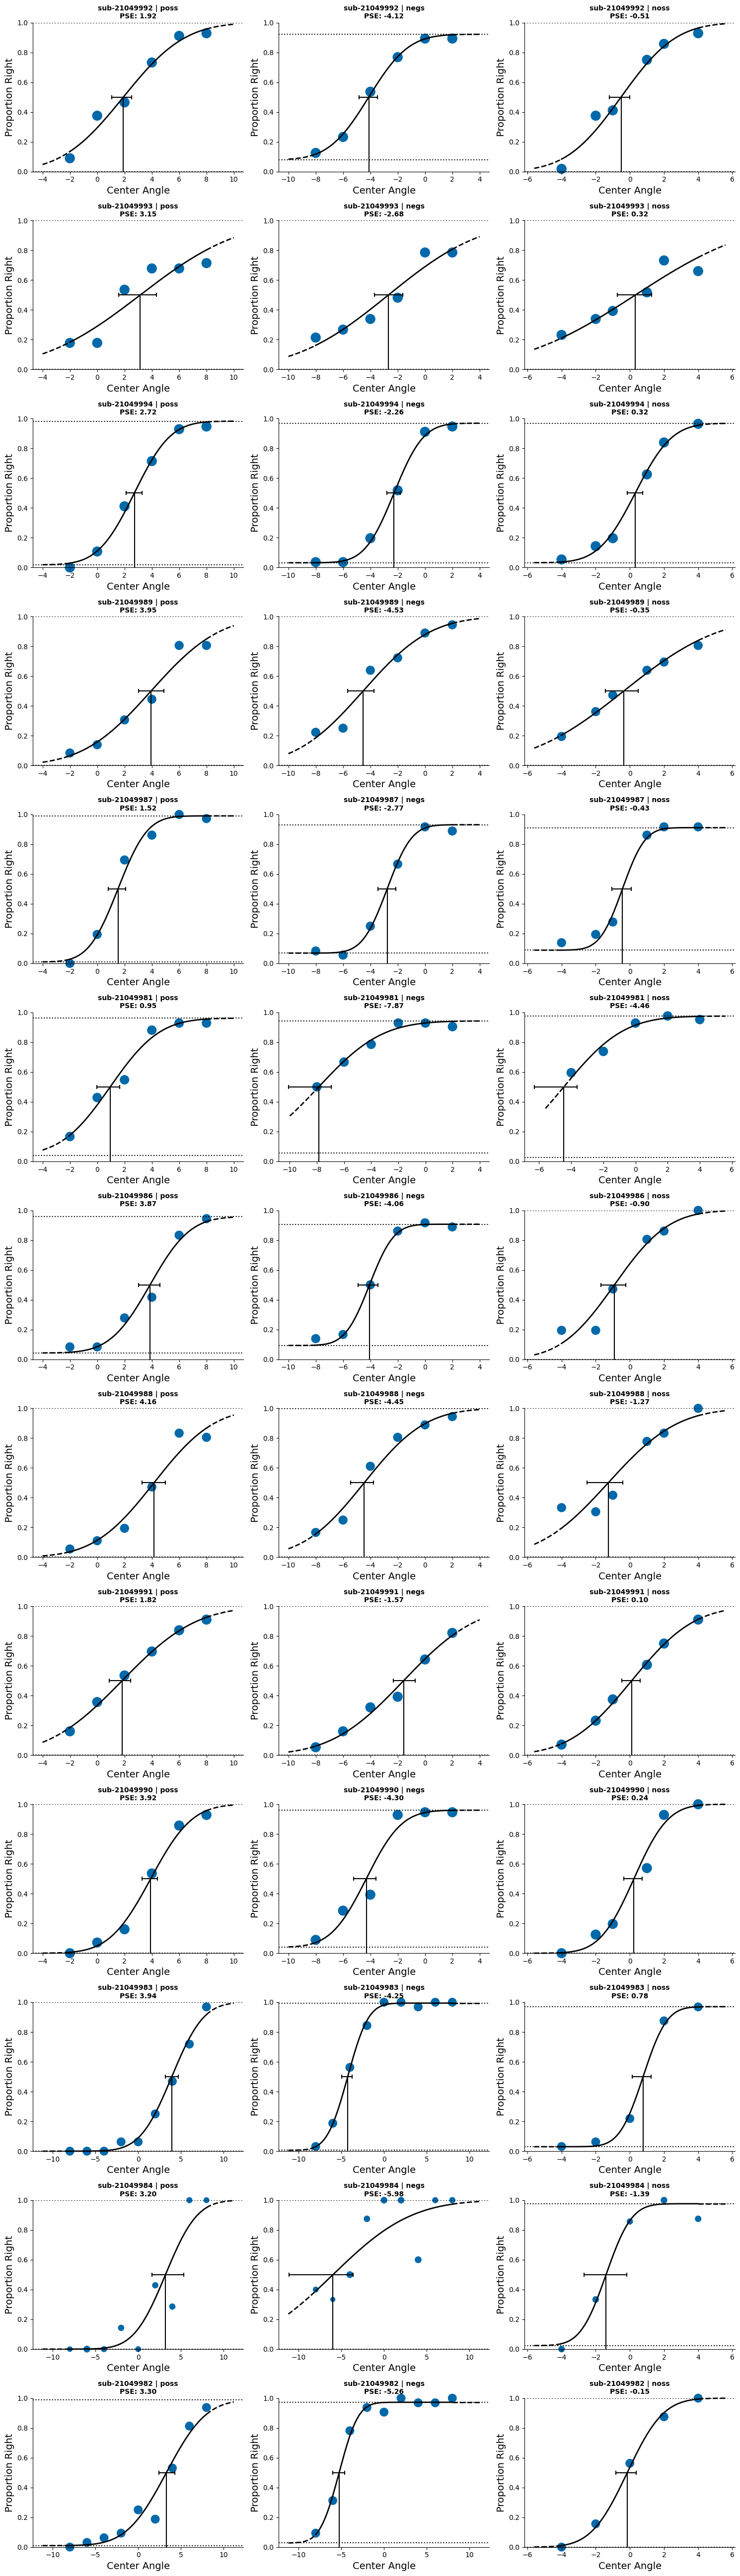

In [ ]:
import numpy as np

# Create mega plot with one big figure
total_sessions = sum(len(sessions) for sessions in data_files.values())

if total_sessions > 0:
    n_cols = 3  # 3 surround conditions per subject
    n_rows = total_sessions

    fig = plt.figure(figsize=(15, 4*n_rows))

    plot_idx = 1
    for sub, sessions in data_files.items():
        for ses in sorted(sessions.keys()):
            file_path = sessions[ses]
            test = pf.get_psignifit_data_from_mocs_csv(file_path)
            fit_results = pf.fit_psychometric_fxn(test)
            
            # Plot each surround type
            for i, surround_cond in enumerate(['poss', 'negs', 'noss']):
                ax = plt.subplot(n_rows, n_cols, plot_idx)
                fit_result = fit_results[surround_cond]
                psp.plot_psychometric_function(fit_result)
                
                pse = fit_result.parameter_estimate['threshold']
                ax.set_title(f'{sub} | {ses} | {surround_cond}\nPSE: {pse:.2f}', fontsize=10, fontweight='bold')
                ax.set_xlabel('Center Angle')
                ax.set_ylabel('Proportion Right')
                
                plot_idx += 1

    plt.tight_layout()
    plt.savefig('psychometric_functions_all_subjects.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No data found to plot.")

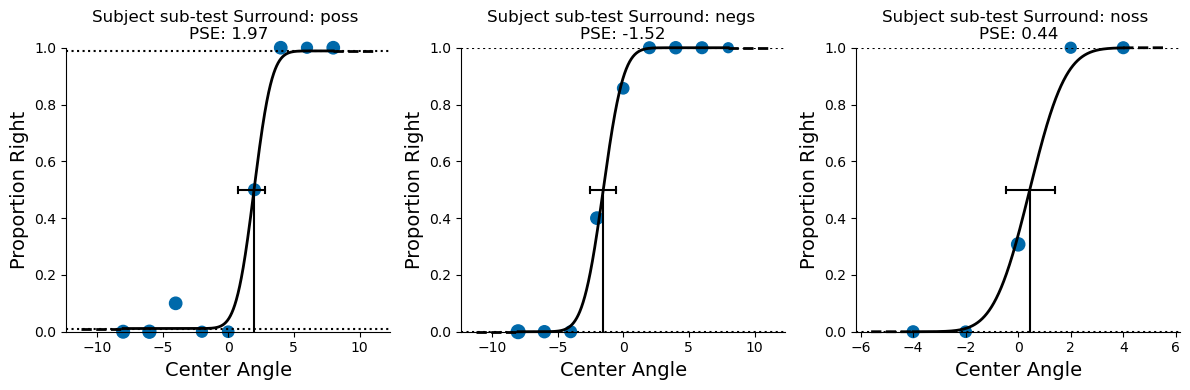

In [2]:
result = pf.get_psignifit_data_from_mocs_csv('/Users/bwinsto2/Documents/Documents - BV-PCR-VPJVMF3/Github/tilt/tilt_mocs/data/sub-test/ses-0/sub-test_ses-0_exp-tiltmocs_2025-12-10_17h32.53.562.csv')
output = pf.fit_psychometric_fxn(result)
pf.plot_psychometric_fxns(output, 'sub-test')
plt.show()